# 01 · Configuración inicial  *(sección 0 del script)*

Este notebook define la **configuración compartida** por todo el pipeline: imports, rutas de trabajo, paleta de colores institucional de Olist y estilo de los gráficos.

Es la **única vez** que se explica celda por celda: los notebooks 02 → 10 repiten este mismo bloque (según lo que necesiten) al principio, para poder correrse de forma independiente.

## Paso 1 — Imports, rutas, paleta y estilo

**Qué hacemos:** importamos las librerías que se usan en todo el pipeline, definimos las rutas de trabajo (raíz del proyecto, `data/raw/`, carpeta de figuras), fijamos la paleta de colores de Olist y el estilo global de matplotlib/seaborn, y silenciamos los warnings para que la salida se lea limpia.

**Para qué:**

- Para no repetir imports en cada bloque y que **todos los gráficos usen la misma paleta**, dando una identidad visual consistente en todo el proyecto.
- Para que las rutas estén definidas en un solo lugar y funcionen **tanto si Jupyter arrancó en la raíz del proyecto como si arrancó en `notebooks/`** (el kernel toma como directorio de trabajo la carpeta del cuaderno).

**Qué importa cada librería y dónde se usa:**

| Librería | Para qué | En qué notebooks |
|---|---|---|
| `pandas` | manipulación de tablas (DataFrames) | todos |
| `numpy` | operaciones numéricas, `NaN`, `np.where`, Haversine | 03 → 07, 10 |
| `matplotlib` | gráficos base y guardado de figuras | 06 → 09 |
| `seaborn` | gráficos estadísticos (`histplot`, `boxplot`, `heatmap`) | 06, 07 |
| `scipy.stats` | tests estadísticos no paramétricos | 10 |
| `collections.Counter` | frecuencia de palabras | 09 |
| `re` / `unicodedata` | limpieza de texto (NLP) | 09 |
| `pathlib.Path` | rutas de archivos multiplataforma | todos |
| `warnings` | silenciar advertencias de las librerías | todos |

> `plotly` (mapa interactivo), `folium` (mapa de calor) y `wordcloud`/`nltk` (NLP) **no** se importan acá: se importan en el notebook donde se usan (08 y 09), junto con su explicación.

In [1]:
%matplotlib inline

import re
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# --- Rutas: raíz del proyecto, aunque el kernel corra desde notebooks/ ---
BASE = Path.cwd()
if not (BASE / "data").exists() and (BASE.parent / "data").exists():
    BASE = BASE.parent

RAW_DIR = BASE / "data" / "raw"
CSV_UNIFICADO = BASE / "data" / "olist_dataset_unificado.csv"
PIPELINE_DIR = BASE / "data" / "pipeline"
FIGS_DIR = BASE / "figuras_eda"

PIPELINE_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(exist_ok=True)

# --- Paleta institucional de Olist ---
OLIST_BLUE = "#0A4EE4"        # azul principal de olist.com
OLIST_BLUE_DARK = "#0D366B"   # azul oscuro, para contraste
OLIST_GRAY = "#52514E"        # gris de ejes y etiquetas
PALETA_CATEGORICA = ["#0A4EE4", "#eb6834", "#1baf7a", "#eda100",
                     "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SUDESTE = {"SP", "RJ", "MG", "ES"}   # estados del eje Sudeste de Brasil

# --- Estilo global de los gráficos ---
sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": OLIST_GRAY,
    "text.color": "#0b0b0b",
    "xtick.color": OLIST_GRAY,
    "ytick.color": OLIST_GRAY,
    "font.family": "sans-serif",
})
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 50)

print("Raíz del proyecto:", BASE)
print("Tablas crudas en :", RAW_DIR)
print("Figuras en        :", FIGS_DIR)

Raíz del proyecto: D:\Ciencia de Datos\Proyecto Integrador\trabajo_ integrador_versionNati\trabajo_ integrador_versionNati
Tablas crudas en : D:\Ciencia de Datos\Proyecto Integrador\trabajo_ integrador_versionNati\trabajo_ integrador_versionNati\data\raw
Figuras en        : D:\Ciencia de Datos\Proyecto Integrador\trabajo_ integrador_versionNati\trabajo_ integrador_versionNati\figuras_eda


**Insight / detalles de la celda anterior:**

- `%matplotlib inline` obliga a que los gráficos se muestren **dentro** del cuaderno (y no en una ventana aparte).
- La detección de `BASE`: si el directorio de trabajo no tiene la carpeta `data/` pero su padre sí, el kernel está corriendo desde `notebooks/` y subimos un nivel. Así el mismo código funciona abierto desde cualquier lugar.
- `PALETA_CATEGORICA` trae **8 colores** pensados para distinguir series categóricas sin repetir azul; `OLIST_BLUE` (#0A4EE4) es el color principal y se usa como color por defecto de las barras/histogramas.
- `SUDESTE` agrupa los estados **SP** (São Paulo), **RJ** (Río de Janeiro), **MG** (Minas Gerais) y **ES** (Espírito Santo): el eje Sudeste brasileño, donde se concentran clientes *y* vendedores. Se usa en la feature `region_sudeste` (notebook 04) y en la hipótesis 3 (notebook 10).
- `warnings.filterwarnings("ignore")` evita que avisos de deprecación de pandas/seaborn tapen los resultados (mismo criterio que el script).

## Paso 2 — Guardado de figuras

**Qué hacemos:** definimos una fábrica de funciones `configurar_guardado(prefijo)`: devuelve una función `guardar_fig()` que guarda la figura actual como PNG dentro de `figuras_eda/`, numerada automáticamente y con el **prefijo del notebook** (`nb01_01.png`, `nb06_03.png`, …).

**Para qué:**

- Un notebook **muestra** los gráficos en pantalla, pero el proyecto además **archiva** cada figura como imagen (mismo criterio que el script, que los guardaba como `fig_XX.png`).
- El prefijo por notebook evita pisar los `fig_XX.png` del script original y hace rastreable qué cuaderno generó qué imagen.

In [2]:
def configurar_guardado(prefijo):
    # Devuelve una función que guarda la figura actual en FIGS_DIR/prefijo_NN.png
    # y devuelve la ruta. El contador es propio de cada notebook.
    FIGS_DIR.mkdir(exist_ok=True)
    contador = {"n": 0}

    def guardar():
        contador["n"] += 1
        ruta = FIGS_DIR / f"{prefijo}_{contador['n']:02d}.png"
        plt.savefig(ruta, dpi=110, bbox_inches="tight")
        return ruta

    return guardar


guardar_fig = configurar_guardado("nb01")
print("Guardado de figuras configurado con prefijo nb01")

Guardado de figuras configurado con prefijo nb01


**Cómo funciona:** `configurar_guardado` usa un *cierre* (closure): la variable `contador` vive dentro de la función y persiste entre llamadas, pero cada notebook tiene el suyo propio porque llama a la fábrica con su propio prefijo.

## Paso 3 — Demostración: primer gráfico

**Qué hacemos:** dibujamos la paleta del pipeline como una tira de colores con el código HEX de cada uno, y la guardamos con `guardar_fig()`.

**Para qué:** para verificar de entrada que matplotlib + el estilo + el guardado de figuras funcionan correctamente antes de llegar a los gráficos reales del análisis.

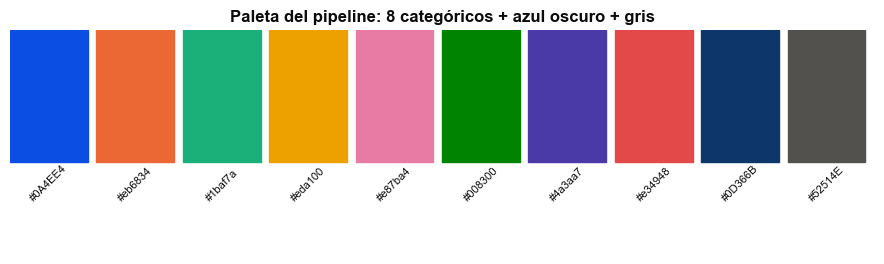

Figura guardada en: figuras_eda\nb01_01.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 2.8))

colores = PALETA_CATEGORICA + [OLIST_BLUE_DARK, OLIST_GRAY]
for i, color in enumerate(colores):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, color=color))
    ax.text(i + 0.45, -0.3, color, ha="center", fontsize=8, rotation=45)

ax.set_xlim(0, len(colores))
ax.set_ylim(-0.7, 1)
ax.set_title("Paleta del pipeline: 8 categóricos + azul oscuro + gris")
ax.axis("off")

plt.tight_layout()
ruta = guardar_fig()
plt.show()
print("Figura guardada en:", ruta.relative_to(BASE))

**Insight:** la tira muestra los 8 colores categóricos (el azul de Olist, naranja, verde, amarillo, rosa, verde oscuro, violeta y rojo — todos diferenciables entre sí y con el fondo blanco), más el azul oscuro y el gris de apoyo. Si este gráfico se ve bien y el archivo aparece en `figuras_eda/nb01_01.png`, la configuración está lista para todo el pipeline.

**Quedó definido en este notebook** (y se repite en los demás cuando hace falta):

- [ ] imports de pandas / numpy / matplotlib / seaborn / scipy
- [ ] rutas `BASE`, `RAW_DIR`, `CSV_UNIFICADO`, `PIPELINE_DIR`, `FIGS_DIR`
- [ ] paleta `OLIST_BLUE`, `PALETA_CATEGORICA`, conjunto `SUDESTE`
- [ ] estilo `whitegrid` + título en negrita
- [ ] fábrica `configurar_guardado(prefijo)` para archivar figuras

**Siguiente paso:** `02_unificacion_de_las_9_tablas.ipynb` — integrar las 9 tablas crudas de Kaggle en una sola tabla.